# 🍷 Red Wine Quality Analysis – Exploratory Data Analysis (EDA)

## 📖 Introduction

In this notebook, we perform an in-depth Exploratory Data Analysis (EDA) on the Red Wine Quality dataset.

The goal of this analysis is to understand:

- What physicochemical properties influence wine quality?
- Which features positively or negatively impact quality ratings?
- Is the dataset balanced or imbalanced?
- How do important chemical properties behave across different quality levels?

This notebook focuses purely on analytical exploration rather than predictive modeling.  
We aim to extract meaningful insights from the dataset using statistical summaries and visualizations.

By the end of this notebook, we will clearly understand which chemical characteristics contribute to higher-quality wines.

# 📊 About the Dataset

This dataset contains physicochemical test results of red variants of Portuguese "Vinho Verde" wine.

Each row represents a wine sample, and the columns describe various chemical properties measured in laboratory conditions.

The target variable is a sensory quality score given by human tasters.

## 📌 Input Features (Physicochemical Properties)

1. **Fixed Acidity**  
   Refers to non-volatile acids (mainly tartaric acid) that do not evaporate easily.

2. **Volatile Acidity**  
   Represents acetic acid content. High values may result in an unpleasant vinegar taste.

3. **Citric Acid**  
   Adds freshness and flavor to wine. Usually present in small amounts.

4. **Residual Sugar**  
   Amount of sugar remaining after fermentation.

5. **Chlorides**  
   Represents salt content in wine.

6. **Free Sulfur Dioxide**  
   Free form of SO₂ that prevents microbial growth and oxidation.

7. **Total Sulfur Dioxide**  
   Total amount of SO₂ (free + bound).

8. **Density**  
   Density of wine, often related to alcohol and sugar levels.

9. **pH**  
   Measures acidity/basicity of wine. Lower pH means higher acidity.

10. **Sulphates**  
   Contribute to wine preservation and may enhance flavor intensity.

11. **Alcohol**  
   Alcohol percentage in wine. Often associated with body and quality.

---

## 🎯 Target Variable

12. **Quality**  
   A sensory score ranging from 0 to 10 given by wine experts.

In this notebook, we also create a binary feature:
- Quality ≥ 7 → Good Wine
- Quality < 7 → Not Good Wine

This helps us better understand high-quality wines.

In [1]:
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns


from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/red-wine-quality-cortez-et-al-2009/winequality-red.csv')

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.400,0.700,0.000,1.900,0.076,11.000,34.000,0.998,3.510,0.560,9.400,5
1,7.800,0.880,0.000,2.600,0.098,25.000,67.000,0.997,3.200,0.680,9.800,5
2,7.800,0.760,0.040,2.300,0.092,15.000,54.000,0.997,3.260,0.650,9.800,5
3,11.200,0.280,0.560,1.900,0.075,17.000,60.000,0.998,3.160,0.580,9.800,6
4,7.400,0.700,0.000,1.900,0.076,11.000,34.000,0.998,3.510,0.560,9.400,5


In [3]:
print("Shape of dataset:", df.shape)
print("\n")

print("Column Names:")
print(df.columns)
print("\n")

print("Data Types:")
print(df.dtypes)
print("\n")

print("Missing Values:")
print(df.isnull().sum())
print("\n")

print("Statistical Summary:")
df.describe()

Shape of dataset: (1599, 12)


Column Names:
Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')


Data Types:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object


Missing Values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality      

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000,1599.000
mean,8.320,0.528,0.271,2.539,0.087,15.875,46.468,0.997,3.311,0.658,10.423,5.636
std,1.741,0.179,0.195,1.410,0.047,10.460,32.895,0.002,0.154,0.170,1.066,0.808
min,4.600,0.120,0.000,0.900,0.012,1.000,6.000,0.990,2.740,0.330,8.400,3.000
25%,7.100,0.390,0.090,1.900,0.070,7.000,22.000,0.996,3.210,0.550,9.500,5.000
50%,7.900,0.520,0.260,2.200,0.079,14.000,38.000,0.997,3.310,0.620,10.200,6.000
75%,9.200,0.640,0.420,2.600,0.090,21.000,62.000,0.998,3.400,0.730,11.100,6.000
max,15.900,1.580,1.000,15.500,0.611,72.000,289.000,1.004,4.010,2.000,14.900,8.000


Unique Quality Scores: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


Value Counts:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


Percentage Distribution:
quality
3    0.625
4    3.315
5   42.589
6   39.900
7   12.445
8    1.126
Name: proportion, dtype: float64


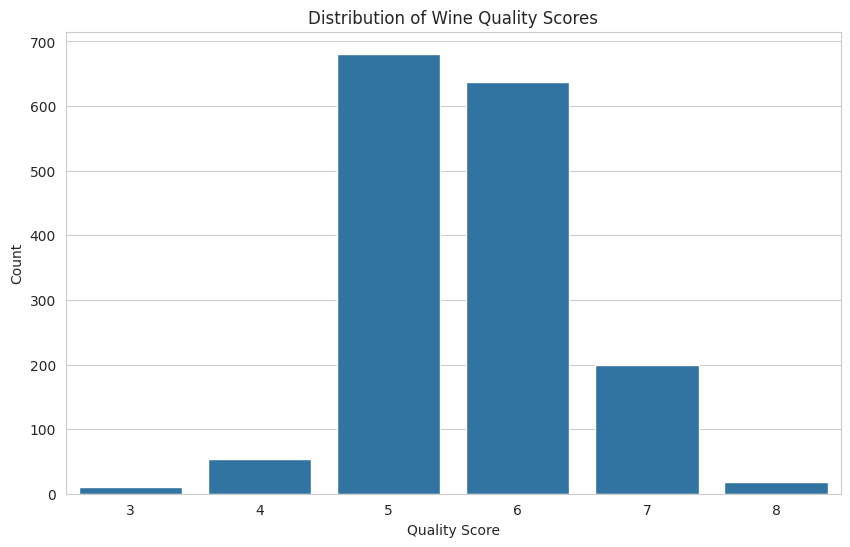

In [4]:
print("Unique Quality Scores:", sorted(df['quality'].unique()))
print("\n")

print("Value Counts:")
print(df['quality'].value_counts().sort_index())
print("\n")

print("Percentage Distribution:")
print((df['quality'].value_counts(normalize=True) * 100).sort_index())

plt.figure()
sns.countplot(x='quality', data=df)

plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality Score")
plt.ylabel("Count")
plt.show()

good_wine
0    1382
1     217
Name: count, dtype: int64


Percentage Distribution:
good_wine
0   86.429
1   13.571
Name: proportion, dtype: float64


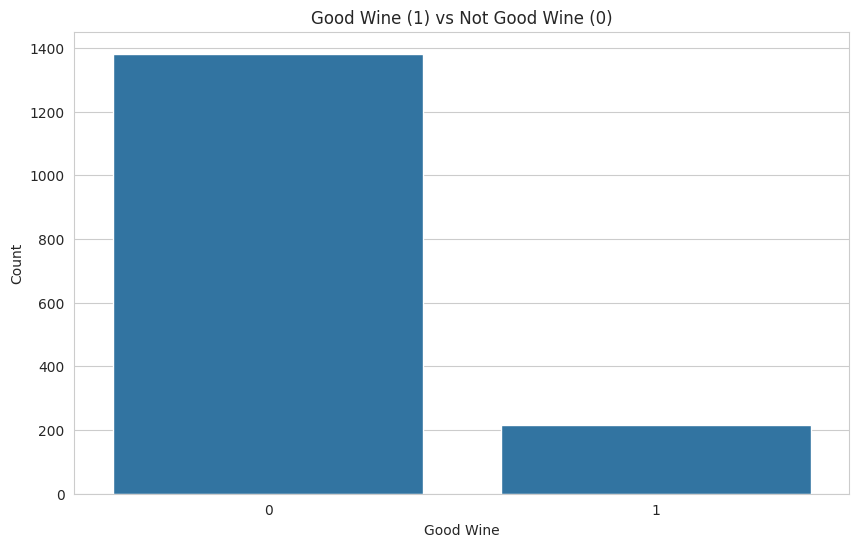

In [5]:
df['good_wine'] = np.where(df['quality'] >= 7, 1, 0)

print(df['good_wine'].value_counts())
print("\n")

print("Percentage Distribution:")
print(df['good_wine'].value_counts(normalize=True) * 100)

plt.figure()
sns.countplot(x='good_wine', data=df)

plt.title("Good Wine (1) vs Not Good Wine (0)")
plt.xlabel("Good Wine")
plt.ylabel("Count")
plt.show()

count   1599.000
mean      10.423
std        1.066
min        8.400
25%        9.500
50%       10.200
75%       11.100
max       14.900
Name: alcohol, dtype: float64


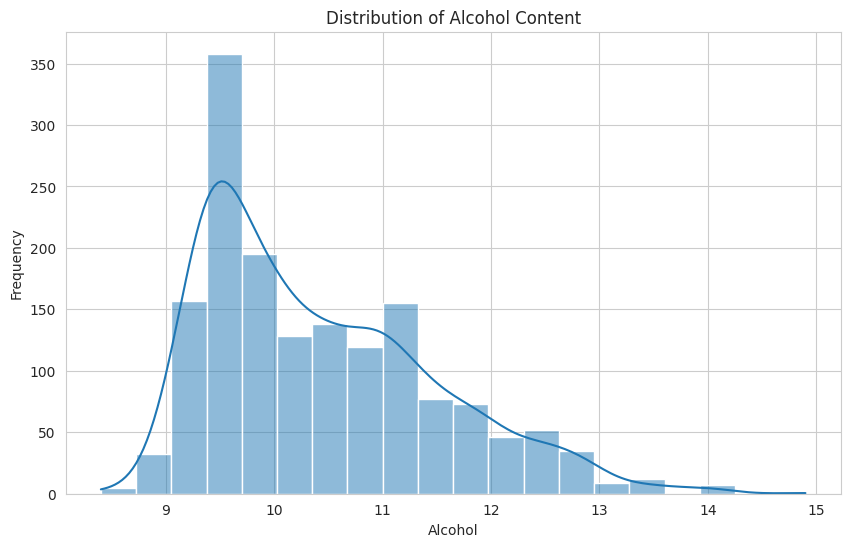

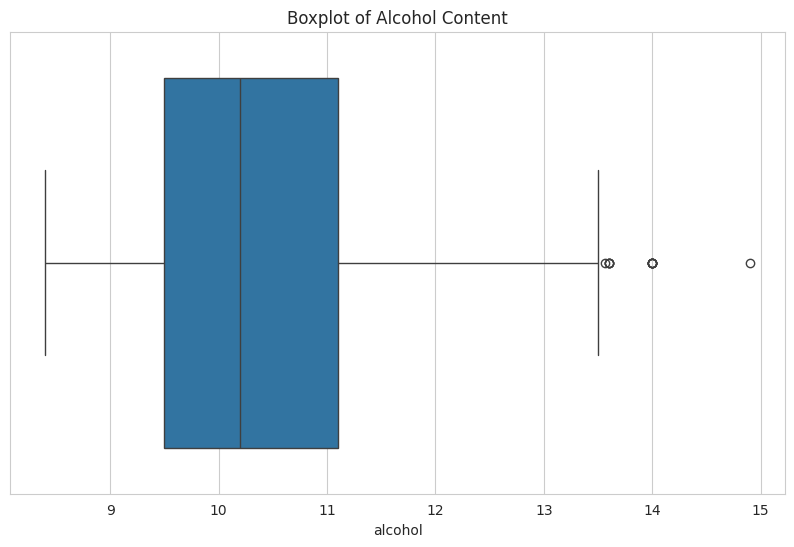

In [6]:
print(df['alcohol'].describe())

plt.figure()
sns.histplot(df['alcohol'], bins=20, kde=True)

plt.title("Distribution of Alcohol Content")
plt.xlabel("Alcohol")
plt.ylabel("Frequency")
plt.show()

plt.figure()
sns.boxplot(x=df['alcohol'])

plt.title("Boxplot of Alcohol Content")
plt.show()

count   1599.000
mean       0.528
std        0.179
min        0.120
25%        0.390
50%        0.520
75%        0.640
max        1.580
Name: volatile acidity, dtype: float64


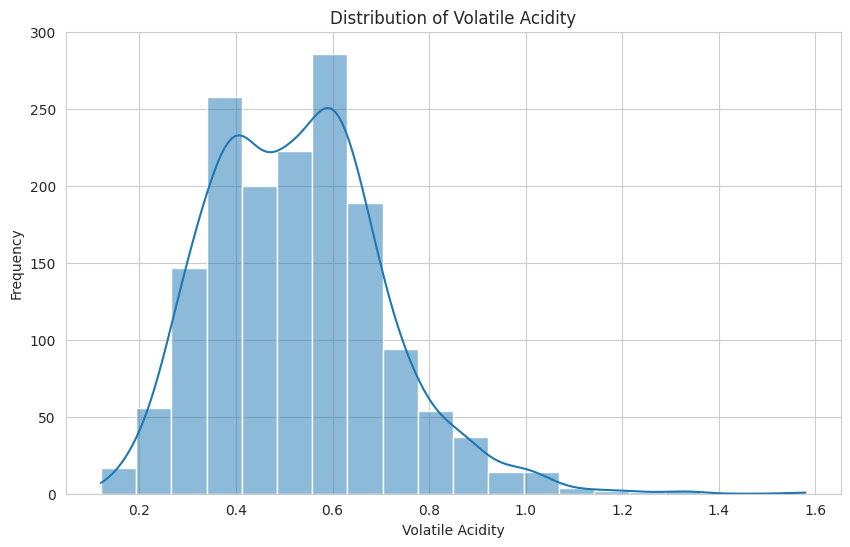

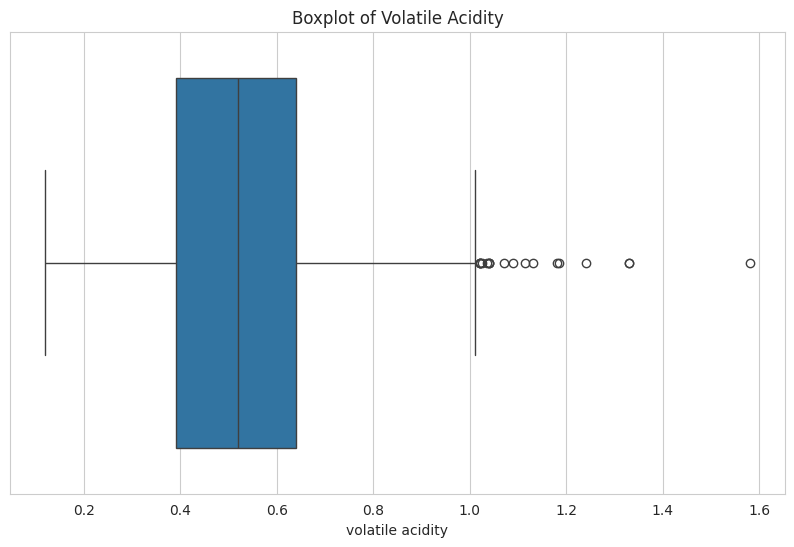

In [7]:
print(df['volatile acidity'].describe())

plt.figure()
sns.histplot(df['volatile acidity'], bins=20, kde=True)

plt.title("Distribution of Volatile Acidity")
plt.xlabel("Volatile Acidity")
plt.ylabel("Frequency")
plt.show()

plt.figure()
sns.boxplot(x=df['volatile acidity'])

plt.title("Boxplot of Volatile Acidity")
plt.show()

Correlation with Quality:
quality                 1.000
good_wine               0.710
alcohol                 0.476
sulphates               0.251
citric acid             0.226
fixed acidity           0.124
residual sugar          0.014
free sulfur dioxide    -0.051
pH                     -0.058
chlorides              -0.129
density                -0.175
total sulfur dioxide   -0.185
volatile acidity       -0.391
Name: quality, dtype: float64


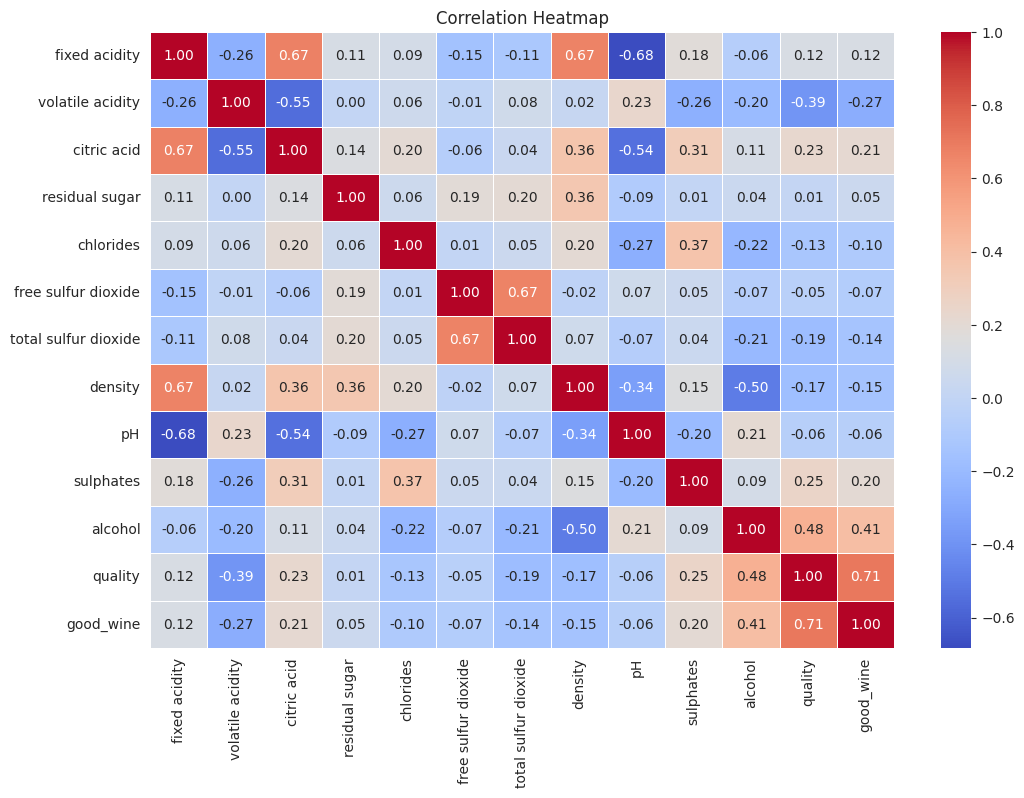

In [8]:
corr_matrix = df.corr()

print("Correlation with Quality:")
print(corr_matrix['quality'].sort_values(ascending=False))

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

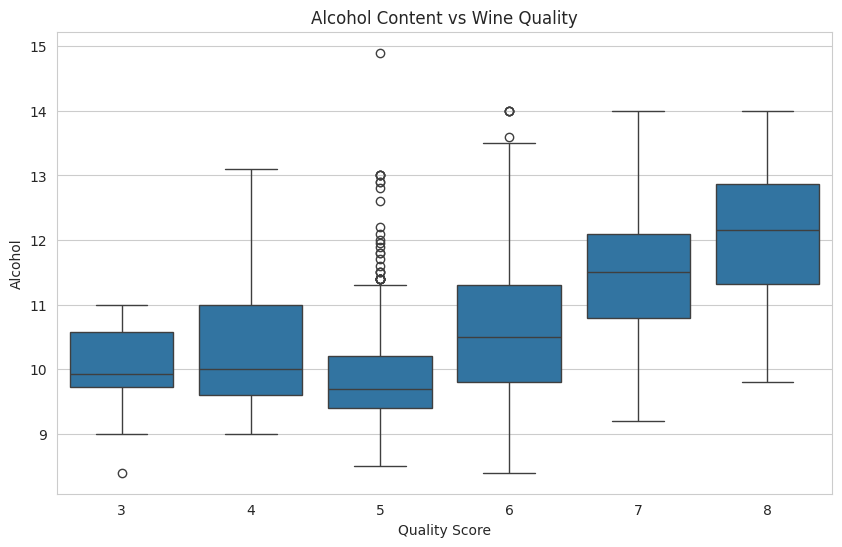

In [9]:
plt.figure()
sns.boxplot(x='quality', y='alcohol', data=df)

plt.title("Alcohol Content vs Wine Quality")
plt.xlabel("Quality Score")
plt.ylabel("Alcohol")
plt.show()

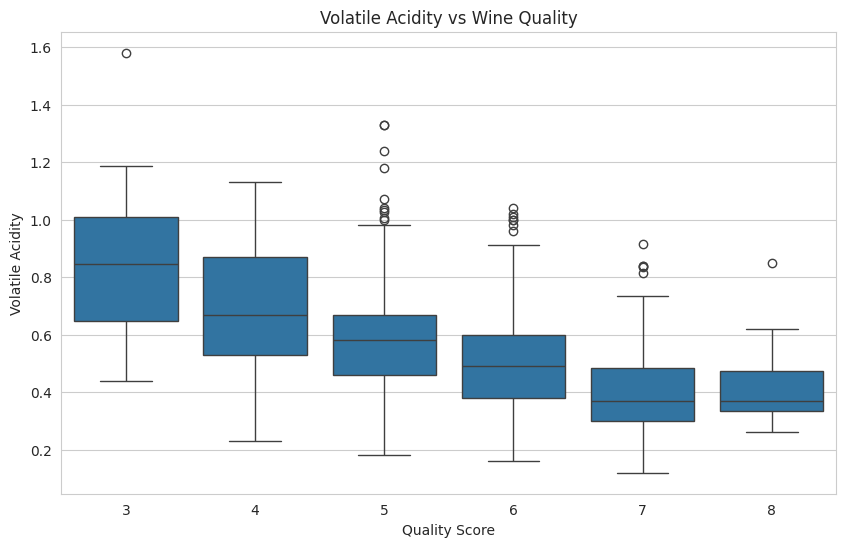

In [10]:
plt.figure()
sns.boxplot(x='quality', y='volatile acidity', data=df)

plt.title("Volatile Acidity vs Wine Quality")
plt.xlabel("Quality Score")
plt.ylabel("Volatile Acidity")
plt.show()

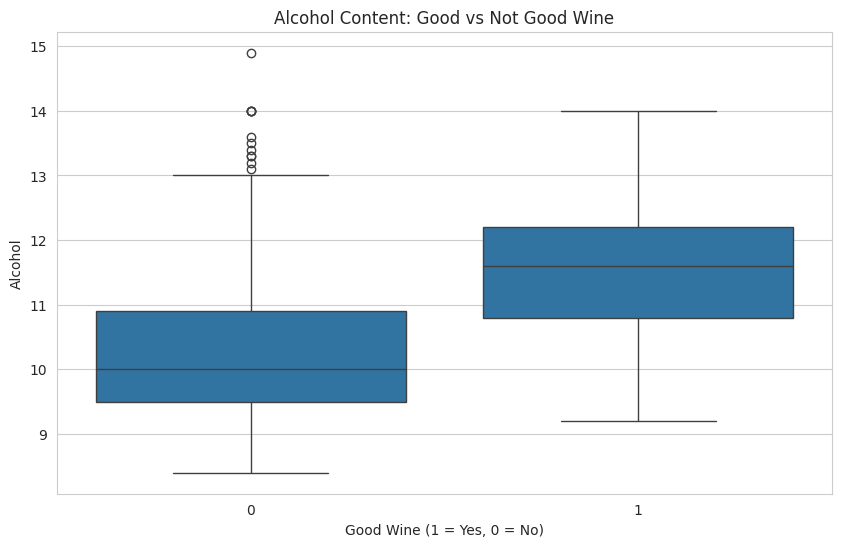

In [11]:
plt.figure()
sns.boxplot(x='good_wine', y='alcohol', data=df)

plt.title("Alcohol Content: Good vs Not Good Wine")
plt.xlabel("Good Wine (1 = Yes, 0 = No)")
plt.ylabel("Alcohol")
plt.show()

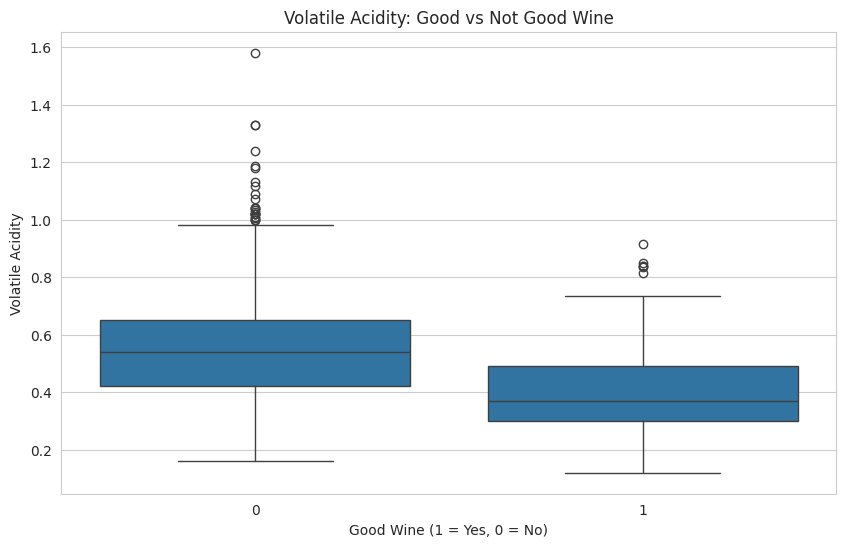

In [12]:
plt.figure()
sns.boxplot(x='good_wine', y='volatile acidity', data=df)

plt.title("Volatile Acidity: Good vs Not Good Wine")
plt.xlabel("Good Wine (1 = Yes, 0 = No)")
plt.ylabel("Volatile Acidity")
plt.show()

# 🏁 Final Conclusion

In this exploratory data analysis of the Red Wine Quality dataset, we examined how various physicochemical properties influence wine quality.

## 🔍 Key Findings

### 1️⃣ Class Imbalance
- The dataset is highly imbalanced.
- Approximately 86% of wines are classified as not good (quality < 7).
- Only about 14% of wines are high-quality (quality ≥ 7).
- This imbalance is important for any future predictive modeling.

---

### 2️⃣ Alcohol is the Strongest Positive Driver
- Alcohol shows the highest positive correlation with quality.
- As alcohol content increases, wine quality tends to increase.
- High-quality wines consistently exhibit higher median alcohol levels.

---

### 3️⃣ Volatile Acidity is the Strongest Negative Driver
- Volatile acidity has a strong negative correlation with quality.
- Wines with higher volatile acidity tend to receive lower ratings.
- High-quality wines are concentrated in lower volatile acidity ranges.

---

### 4️⃣ Moderate Contributors
- Sulphates and citric acid show moderate positive relationships with quality.
- Density and total sulfur dioxide show mild negative relationships.

---

### 5️⃣ Chemical Interpretation
The analysis suggests that:
- Higher alcohol and balanced acidity contribute to better perceived quality.
- Excessive volatile acidity negatively impacts taste.
- The dataset shows logical chemical relationships between acidity, pH, and sulfur compounds.

---

## 📌 Overall Insight

Wine quality in this dataset appears to be primarily influenced by alcohol content and volatile acidity.

This exploratory analysis provides a strong foundation for future predictive modeling and feature engineering.

Further work could include classification modeling, feature importance analysis, and performance evaluation using metrics such as ROC-AUC.

---

🍷 This concludes the exploratory analysis of Red Wine Quality.